##### Most visualization is done by AI -rest of code i've written myself', i find the syntax,color picking CSS level of annoying T-T but i've guided the AI - https://claude.ai/share/8052ae95-3f83-48ae-8ced-64f29c203ff4

## Imports

In [17]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import os 
import colorsys
import numpy as np
from data_explorer_class import DataExplorer
from data_cleaning_class import DataCleaner
pd.set_option('display.max_columns' , None)
#- some of the functions or lines can be squeezed by using kwargs to also improve generality but i thought keeping it task specific would make it easier to implement and readable

## Analysis Class

In [18]:

class FootballAnalysis():
    def __init__(self , clean = False):
        #loading data
        self.script_dir = os.getcwd()
        self.load_dataframes()

        #doesn't clean automatically , in case of exploring the data first for integrity  
        self.clean = clean
        if self.clean:
             self.clean_data_frames()
             self.cleaned = True
             

    def load_dataframes(self):
            self.former_names_path = self.__building_csv_path("former_names")
            self.goal_scorers_path = self.__building_csv_path("goalscorers")
            self.results_path      = self.__building_csv_path("results")
            self.shootouts_path    = self.__building_csv_path("shootouts")

            self.df_results      = self.__read_csv(self.results_path)
            self.df_former_names = self.__read_csv(self.former_names_path)
            self.df_goal_scorers = self.__read_csv(self.goal_scorers_path)
            self.df_shootouts    = self.__read_csv(self.shootouts_path)

    def __building_csv_path(self , csv_name):
        return os.path.join(self.script_dir , f"{csv_name}.csv")

    def __read_csv(self, path) :
        df = pd.read_csv(path, on_bad_lines='skip').replace(r'"', '', regex=True)
        df.columns = df.columns.str.strip()
        return df

    def exploring_dataframes(self):
        #data exploring --i've built this class in previous work--
        #i like to explore the data first before looking even at the task, then i inspect it again after seeing the task
        results_exp      = DataExplorer(self.results_path)
        former_names_exp = DataExplorer(self.former_names_path) 
        goal_scorers_exp = DataExplorer(self.goal_scorers_path)
        shootouts_exp    = DataExplorer(self.shootouts_path)

        self.__explore_csv(results_exp)
        self.__explore_csv(former_names_exp)
        self.__explore_csv(goal_scorers_exp)
        self.__explore_csv(shootouts_exp)

    def __explore_csv(exp : DataExplorer):
        exp.basic_structure()
        exp.values_inspection()
        exp.check_outliers()
        exp.get_duplicates()
        exp.check_for_skewness()
        exp.get_correlations()

    def clean_data_frames(self):
            self.__map_former_names(self.df_results, self.df_former_names)
            self.__map_former_names(self.df_goal_scorers,  self.df_former_names)
            self.__map_former_names(self.df_shootouts, self.df_former_names)

            #
            self.df_results      = DataCleaner(self.df_results).clean_df()
            self.df_shootouts    = DataCleaner(self.df_shootouts).clean_df()
            self.df_goal_scorers = DataCleaner(self.df_goal_scorers).clean_df()

            self.cleaned = True
            

    #renaming the countries using former names.csv, i looked at mapping method using dict(zip), as i read its faster because its factorized 
    #but the data here is date-dependent
    def __map_former_names(self ,df : pd.DataFrame , mapping_csv : pd.DataFrame):
        for current , former , start_date , end_date in mapping_csv.itertuples(index= False , name= None):
            mask = (df["date"] >= start_date) & (df["date"] <= end_date)#masking the interval only to make it faster
            df.loc[mask , "home_team"]= df.loc[mask, "home_team"].replace(former, current)
            df.loc[mask , "away_team"]= df.loc[mask, "away_team"].replace(former, current)

    def top_10_performers(self):
        if not self.cleaned :
             self.clean_data_frames()
             self.cleaned = True
        ## 2.11 Top 10 national teams with most goals 
        # df_goal_scorers.groupby("team" , as_index= Falsewhat )
        teams_ranking = (
                self.df_goal_scorers["team"].value_counts().reset_index().head(10)
            )

        scorers_ranking = (
                self.df_goal_scorers["scorer"].value_counts().reset_index().head(10)
            )

        print(teams_ranking) #didn't know germany was that strong
        print(scorers_ranking)  

        #Visual
        sns.set_theme(style="whitegrid")

        # --- Teams chart ---
        plt.figure(figsize=(10, 6))
        ax1 = sns.barplot(
            data=teams_ranking,
            x="count",
            y="team",
            color="#4C72B0",   # muted blue, no neon
            width=0.6,          # controls bar thickness -> spacing between bars
        )
        ax1.set_title("Top 10 National Teams by Goals Scored", fontsize=14, weight="bold")
        ax1.set_xlabel("Goals")
        ax1.set_ylabel("Team")
        sns.despine(left=True, bottom=True)
        plt.tight_layout()
        plt.show()

        # --- Scorers chart ---
        plt.figure(figsize=(10, 6))
        ax2 = sns.barplot(
            data=scorers_ranking,
            x="count",
            y="scorer",
            color="#55A868",   # muted green
            width=0.6,
        )
        ax2.set_title("Top 10 Goal Scorers", fontsize=14, weight="bold")
        ax2.set_xlabel("Goals")
        ax2.set_ylabel("Scorer")
        sns.despine(left=True, bottom=True)
        plt.tight_layout()
        plt.show()

    def top_10_efficiency(self):
        if not self.cleaned :
             self.clean_data_frames()
             self.cleaned = True

        scenarios = [ 
                 self.df_results["home_score"] > self.df_results["away_score"],
                 self.df_results["home_score"] ==self.df_results["away_score"],
                 self.df_results["home_score"] < self.df_results["away_score"]
             ]
         
        home_pts = [3 , 1 , 0]
        away_pts = [0 , 1 , 3]
         
        self.df_results["home_pts"] = np.select(condlist= scenarios , choicelist= home_pts)
        self.df_results["away_pts"] = np.select(condlist= scenarios , choicelist= away_pts)  
         
        # print (df_results.head(10))
        self.df_results["home_efficiency"] = self.df_results["home_pts"] + self.df_results["home_score"]
        self.df_results["away_efficiency"] = self.df_results["away_pts"] + self.df_results["away_score"]
         
        #i was thinking of using groupby over home and away then summing ones with similar team but found df.concat
        #creating dfs with team and efficiency cols
        home_df = self.df_results[["home_team", "home_efficiency","home_pts"]].rename(columns= {"home_team" : "team" , "home_efficiency" : "efficiency" , "home_pts" :"pts"})
        away_df = self.df_results[["away_team", "away_efficiency","away_pts"]].rename(columns= {"away_team" : "team" , "away_efficiency" : "efficiency" , "away_pts" :"pts"})
         
        team = pd.concat([home_df, away_df] , ignore_index= True) #stacks them vertically 
         
        efficiency_ranking = (
                team.groupby("team")["efficiency"].sum().round(2)
                .sort_values(ascending= False).reset_index().head(10)
             )
         
        pts_ranking = (
                team.groupby("team")["pts"].sum().round(0)
                .sort_values(ascending= False).reset_index().head(10)
             )

        print (f"{pts_ranking} \n" )
        print (efficiency_ranking)


        self.plot_pts_vs_efficiency(pts_ranking= pts_ranking , efficiency_ranking= efficiency_ranking)

    #shootouts
    def drama_analysis(self):
        #merging shootouts and result to get tournaments
        merged = self.df_shootouts.merge(
            self.df_results,
            on = ["date" , "home_team" , "away_team"],
            how = "inner" #uses intersection of keys since results.csv dates are more extended
        )
        #split to get the year only
        merged["decade"] = (merged["date"].str.split("-").str[0].astype(int) // 10) * 10
        # print(self.merged["decade"])

        #since we now have only the rows with shootouts
        shootouts_per_decade = merged["decade"].value_counts() #2010-2020 came with most shootouts
        print ("Shootouts per decade")
        print(shootouts_per_decade , "\n\n")

        shootouts_per_tournament = merged["tournament"].value_counts()
        print ("Shootouts per Tournament")
        print(shootouts_per_tournament) #friendly matches had the most shootouts 

        self.plot_drama_analysis(shootouts_per_decade= shootouts_per_decade , shootouts_per_tournament= shootouts_per_tournament)


    def worst_performance(self):
        #remove all rows except ones with first goal
        self.first_scorer_df = self.df_goal_scorers.sort_values('minute').drop_duplicates(subset=["date" , "home_team","away_team"], keep="first")
        # resort by date since that'll make easier foe future usage
        self.first_scorer_df = self.first_scorer_df.sort_values('date')

        #dropping uncessary cols before merging
        self.first_scorer_df = self.first_scorer_df.rename(columns={"team": "first_scorer"}).drop(columns=["scorer", "penalty"])  
        # self.first_scorer_df.to_csv('output.csv' , index = False)

        #merging with results to get winner 
        merged = self.first_scorer_df.merge(
             self.df_results,
             on = ["date" , "home_team" , "away_team"],
             how = 'inner'
        )

        scenarios = [
            (merged["home_score"] > merged["away_score"]) & (merged["first_scorer"] == merged["home_team"]),
            (merged["away_score"] > merged["home_score"]) & (merged["first_scorer"] == merged["away_team"])
        ]

        choices = [True, True]
        merged["lead_won"] = np.select(scenarios ,  choices , default=False)

        worst_performers =(
             merged[merged["lead_won"] == False].groupby("first_scorer").size()
             .sort_values(ascending= False)
        )
        print("Worst Performers by number of failures")
        print (worst_performers) #doesn't make sense that brazil is the worst

        # sorting them by percentage
        total_first_scores = merged.groupby("first_scorer").size()

        failed_first_scores = (
            merged[merged["lead_won"] == False]
            .groupby("first_scorer")
            .size()
        )

        worst_performers = (
            pd.DataFrame({
                "times_scored_first": total_first_scores,
                "failed_after_leading": failed_first_scores
            })
            .fillna(0)  # teams with 0 failures won't appear in failed_first_scores otherwise
            .assign(fail_pct=lambda d: (d["failed_after_leading"] / d["times_scored_first"] * 100).round(1))
            .sort_values("fail_pct", ascending=False)
        )
        print("Worst Performers by percentages")
        print(worst_performers)

        self.plot_worst_performers_bubble(worst_performers_full=worst_performers)
        self.plot_worst_performers_ranked(worst_performers_full= worst_performers)


    def era_comparison(self):
        era_df = self.df_results
        era_df["decade"] = (era_df["date"].str.split("-").str[0].astype(int) // 10) * 10

        result = era_df.groupby("decade").apply(lambda decade: pd.Series(
            {
                 "goals_per_match" : (decade["home_score"] + decade["away_score"]).mean(),
                 "draw_rate"       : (decade["home_score"] == decade["away_score"]).mean(),
                 "avg_margin"      : (decade["home_score"] - decade["away_score"]).abs().mean()
            }
        ))

        #for plotting accurate line charts
        year_df = self.df_results
        year_df["year"] = year_df["date"].str.split("-").str[0].astype(int)
        year_df["year"] = (year_df["year"] // 3) * 3
        yearly_results = year_df.groupby("year").apply(lambda year: pd.Series(
            {
                 "goals_per_match" : (year["home_score"] + year["away_score"]).mean(),
                 "draw_rate"       : (year["home_score"] == year["away_score"]).mean(),
                 "avg_margin"      : (year["home_score"] - year["away_score"]).abs().mean()
            }
        ))

        
        print(result)
        self.plot_era_comparison(yearly_results)

    ##-----------------------
    ## VISUALS 
    ##-----------------------
    def plot_pts_vs_efficiency(self, pts_ranking, efficiency_ranking, top_n=10):
        top_teams = pd.Index(
            pts_ranking["team"].head(top_n).tolist()
            + efficiency_ranking["team"].head(top_n).tolist()
        ).unique()[:top_n]

        combined = pd.merge(
            pts_ranking[pts_ranking["team"].isin(top_teams)],
            efficiency_ranking[efficiency_ranking["team"].isin(top_teams)],
            on="team",
            how="outer"
        ).fillna(0)

        teams = combined["team"].tolist()
        x = np.arange(len(teams))
        width = 0.35

        pts_base, pts_dark = "#6C7FD8", "#3B4A9E"
        eff_base, eff_dark = "#F2A65A", "#B96E1F"

        top_pts_team = pts_ranking.iloc[0]["team"]
        top_eff_team = efficiency_ranking.iloc[0]["team"]

        pts_colors = [pts_dark if t == top_pts_team else pts_base for t in teams]
        eff_colors = [eff_dark if t == top_eff_team else eff_base for t in teams]

        sns.set_theme(style="whitegrid")
        fig, ax1 = plt.subplots(figsize=(12, 7))
        ax2 = ax1.twinx()

        bars1 = ax1.bar(x - width/2, combined["pts"], width, color=pts_colors, label="Points")
        bars2 = ax2.bar(x + width/2, combined["efficiency"], width, color=eff_colors, label="Efficiency")

        # value labels
        for bar in bars1:
            h = bar.get_height()
            ax1.annotate(f"{h:.0f}", (bar.get_x() + bar.get_width()/2, h),
                        ha="center", va="bottom", fontsize=9, color=pts_dark)
        for bar in bars2:
            h = bar.get_height()
            ax2.annotate(f"{h:.0f}", (bar.get_x() + bar.get_width()/2, h),
                        ha="center", va="bottom", fontsize=9, color=eff_dark)

        # axis labels & colors matched to their metric
        ax1.set_ylabel("Points", color=pts_dark, fontsize=12, weight="bold")
        ax2.set_ylabel("Efficiency", color=eff_dark, fontsize=12, weight="bold")
        ax1.tick_params(axis="y", labelcolor=pts_dark)
        ax2.tick_params(axis="y", labelcolor=eff_dark)

        # stretch each axis independently around its own data range
        for ax, col in [(ax1, "pts"), (ax2, "efficiency")]:
            vmin, vmax = combined[col].min(), combined[col].max()
            pad = (vmax - vmin) * 0.15 or 1
            ax.set_ylim(max(0, vmin - pad), vmax + pad)

        ax1.set_xticks(x)
        ax1.set_xticklabels(teams, rotation=45, ha="right")
        ax1.set_xlabel("Team")
        ax1.set_title("Points vs Scoring Efficiency — Same Rank, Different Story", fontsize=14, weight="bold")

        # combined legend
        handles = [bars1[0], bars2[0]]
        labels = ["Points (left axis)", "Efficiency (right axis)"]
        ax1.legend(handles, labels, loc="upper right")

        sns.despine(left=False, right=False, top=True)
        ax1.grid(axis="y", alpha=0.3)
        ax2.grid(False)  # avoid double gridlines from two axes

        plt.tight_layout()
        plt.show()


    def plot_drama_analysis(self, shootouts_per_decade, shootouts_per_tournament, top_n=10):
        # sort decade chronologically for a proper line trend
        decade_df = shootouts_per_decade.sort_index().reset_index()
        decade_df.columns = ["decade", "count"]

        # keep only top N tournaments for readability
        tournament_df = shootouts_per_tournament.head(top_n).reset_index()
        tournament_df.columns = ["tournament", "count"]

        sns.set_theme(style="dark")

        # reddish "drama" palette
        line_color = "#B02A2A"        # deep red for the trend line
        marker_color = "#7A1F1F"      # darker red for markers
        bar_base = "#E07A5F"          # warm reddish-orange base
        bar_dark = "#9C2C2C"          # darker red for the top tournament

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # --- Line chart: shootouts per decade ---
        ax1.plot(
            decade_df["decade"], decade_df["count"],
            color=line_color, linewidth=2.5, marker="o",
            markersize=8, markerfacecolor=marker_color, markeredgecolor="white"
        )
        ax1.fill_between(decade_df["decade"], decade_df["count"], color=line_color, alpha=0.1)

        for x, y in zip(decade_df["decade"], decade_df["count"]):
            ax1.annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color=marker_color)

        ax1.set_title("Shootouts per Decade", fontsize=13, weight="bold", color="#5A1515")
        ax1.set_xticks(decade_df["decade"])
        sns.despine(ax=ax1, left=True)
        ax1.grid(axis="y", alpha=0.3)

        # --- Bar chart: shootouts per tournament ---
        top_tournament = tournament_df.iloc[0]["tournament"]
        colors = [bar_dark if t == top_tournament else bar_base for t in tournament_df["tournament"]]

        bars = ax2.bar(
            tournament_df["tournament"], tournament_df["count"],
            color=colors, width=0.6
        )
        for bar in bars:
            h = bar.get_height()
            ax2.annotate(f"{h:.0f}", (bar.get_x() + bar.get_width()/2, h),
                        ha="center", va="bottom", fontsize=9, color="#5A1515")

        ax2.set_title(f"Shootouts per Tournament (Top {top_n})", fontsize=13, weight="bold", color="#5A1515")
        plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
        sns.despine(ax=ax2, left=True)
        ax2.grid(axis="y", alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


    def plot_worst_performers_bubble(self, worst_performers_full, annotate_top_n=3):
        df = worst_performers_full.reset_index().rename(columns={"index": "first_scorer"})

        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(figsize=(12, 8))

        cmap = sns.color_palette("Blues", as_cmap=True)
        norm = mcolors.Normalize(vmin=df["fail_pct"].min(), vmax=df["fail_pct"].max())
        sizes = (df["failed_after_leading"] + 1) * 40

        scatter = ax.scatter(
            df["times_scored_first"],
            df["fail_pct"],
            s=sizes,
            c=df["fail_pct"],
            cmap=cmap,
            norm=norm,
            alpha=0.7,
            edgecolors="#2C5F8A",
            linewidth=1.0
        )

        # only annotate the extremes, not every bubble
        outliers = df.sort_values("fail_pct", ascending=False).head(annotate_top_n)
        for _, row in outliers.iterrows():
            ax.annotate(
                row["first_scorer"],
                (row["times_scored_first"], row["fail_pct"]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, weight="bold", color="#1B3A57"
            )

        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("Fail % (color)", fontsize=10)

        ax.set_xlabel("Times Scored First (sample size)")
        ax.set_ylabel("Fail % After Leading")
        ax.set_title("Worst Performers: Fail % vs Sample Size (bubble = failure count)",
                    fontsize=14, weight="bold", color="#1B3A57")
        sns.despine(left=True, bottom=True)
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


    def plot_worst_performers_ranked(self, worst_performers_full, top_n=10):
            df = worst_performers_full.reset_index().rename(columns={"index": "first_scorer"})

            top_by_count = df.sort_values("failed_after_leading", ascending=False).head(top_n)
            top_by_pct = df.sort_values("fail_pct", ascending=False).head(top_n)

            sns.set_theme(style="whitegrid")
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

            bar_base = "#6FA8DC"
            bar_dark = "#2C5F8A"

            # --- left: ranked by raw failure count, bar length = count, label shows % ---
            colors1 = [bar_dark if i == 0 else bar_base for i in range(len(top_by_count))]
            bars1 = ax1.barh(top_by_count["first_scorer"], top_by_count["failed_after_leading"],
                            color=colors1, height=0.6)
            ax1.invert_yaxis()  # highest at top
            for bar, pct in zip(bars1, top_by_count["fail_pct"]):
                w = bar.get_width()
                ax1.annotate(f"{pct:.1f}%", (w, bar.get_y() + bar.get_height()/2),
                            va="center", ha="left", fontsize=9, xytext=(4, 0), textcoords="offset points",
                            color="#1B3A57")
            ax1.set_title(f"Top {top_n} by Raw Failure Count", fontsize=13, weight="bold", color="#1B3A57")
            ax1.set_xlabel("Failed After Leading (count)")
            sns.despine(ax=ax1, left=True, bottom=True)

            # --- right: ranked by percentage, bar length = fail_pct, label shows n ---
            colors2 = [bar_dark if i == 0 else bar_base for i in range(len(top_by_pct))]
            bars2 = ax2.barh(top_by_pct["first_scorer"], top_by_pct["fail_pct"],
                            color=colors2, height=0.6)
            ax2.invert_yaxis()
            for bar, total in zip(bars2, top_by_pct["times_scored_first"]):
                w = bar.get_width()
                ax2.annotate(f"n={total:.0f}", (w, bar.get_y() + bar.get_height()/2),
                            va="center", ha="left", fontsize=9, xytext=(4, 0), textcoords="offset points",
                            color="#1B3A57")
            ax2.set_title(f"Top {top_n} by Fail Percentage", fontsize=13, weight="bold", color="#1B3A57")
            ax2.set_xlabel("Fail % After Leading")
            sns.despine(ax=ax2, left=True, bottom=True)

            fig.suptitle("Worst Performers — Ranked by Count vs by Rate", fontsize=15, weight="bold", color="#1B3A57")
            plt.tight_layout(rect=[0, 0, 1, 0.94])
            plt.show()


    def plot_era_comparison(self, yearly_results):
            from scipy.interpolate import make_interp_spline

            df = yearly_results.reset_index()  # brings "year" back as a column

            # identify which years are decade boundaries (1930, 1940, ... )
            df["is_decade"] = (df["year"] % 10 == 0)
            decade_points = df[df["is_decade"]]

            sns.set_theme(style="whitegrid")
            fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)

            metrics = [
                ("goals_per_match", "Goals per Match", "#4C72B0"),
                ("draw_rate", "Draw Rate", "#55A868"),
                ("avg_margin", "Average Margin", "#C44E52"),
            ]

            for ax, (col, title, color) in zip(axes, metrics):
                x = df["year"].values
                y = df[col].values

                # build a smooth curve: more points along x, spline-interpolated y
                x_smooth = np.linspace(x.min(), x.max(), 500)
                spline = make_interp_spline(x, y, k=3)  # cubic spline
                y_smooth = spline(x_smooth)

                # smoothed curve instead of the raw jagged line
                ax.plot(x_smooth, y_smooth, color=color, linewidth=1.4, alpha=0.7, zorder=1)

                # bold markers only on decade years (still plotted at their real, unsmoothed values)
                ax.scatter(
                    decade_points["year"], decade_points[col],
                    color=color, s=70, zorder=3, edgecolor="white", linewidth=1.2
                )

                # label each decade point with its value
                for _, row in decade_points.iterrows():
                    ax.annotate(
                        f"{row[col]:.2f}",
                        (row["year"], row[col]),
                        textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8, color=color, weight="bold"
                    )

                # vertical guide lines at each decade for easy visual reference
                for dec_year in decade_points["year"]:
                    ax.axvline(dec_year, color="grey", linestyle="--", alpha=0.15, zorder=0)

                ax.set_ylabel(title)
                ax.set_title(f"{title} Over Time", fontsize=12, weight="bold")
                sns.despine(ax=ax, left=True, bottom=True)
                ax.grid(axis="y", alpha=0.3)

            axes[-1].set_xlabel("Year")
            axes[-1].set_xticks(decade_points["year"])
            axes[-1].set_xticklabels(decade_points["year"], rotation=45)

            fig.suptitle("Era Comparison", fontsize=15, weight="bold")
            plt.tight_layout(rect=[0, 0, 1, 0.97])
            plt.show()

    def team_goals_over_years(self, team="Brazil"):
        if not self.cleaned:
            self.clean_data_frames()
            self.cleaned = True

        team_df = self.df_goal_scorers[self.df_goal_scorers["team"] == team].copy()
        team_df["year"] = team_df["date"].str.split("-").str[0].astype(int)

        goals_per_year = (
            team_df.groupby("year").size()
            .reset_index(name="goals")
            .sort_values("year")
        )

        self.plot_team_goals_over_years(goals_per_year, team)

    def plot_team_goals_over_years(self, goals_per_year, team):
        import plotly.express as px

        fig = px.line(
            goals_per_year,
            x="year",
            y="goals",
            markers=True,
            title=f"{team} — Goals Scored per Year"
        )
        fig.update_traces(
            line_color="#F2C14E",
            hovertemplate="Year: %{x}<br>Goals: %{y}<extra></extra>"
        )
        fig.update_layout(
            template="plotly_white",
            xaxis_title="Year",
            yaxis_title="Goals"
        )
        fig.show()


football_analysis = FootballAnalysis(clean= True)

## TOP Performers

          team  count
0       Brazil   1085
1      Germany   1025
2    Argentina    998
3        Spain    952
4  Netherlands    907
5       Mexico    872
6      Uruguay    829
7      England    827
8       France    818
9        Italy    761
                scorer  count
0    Cristiano Ronaldo    124
1           Harry Kane     75
2         Lionel Messi     71
3   Robert Lewandowski     68
4        Romelu Lukaku     67
5           Edin Džeko     58
6        Kylian Mbappé     53
7       Erling Haaland     53
8  Aleksandar Mitrović     52
9          Luis Suárez     51


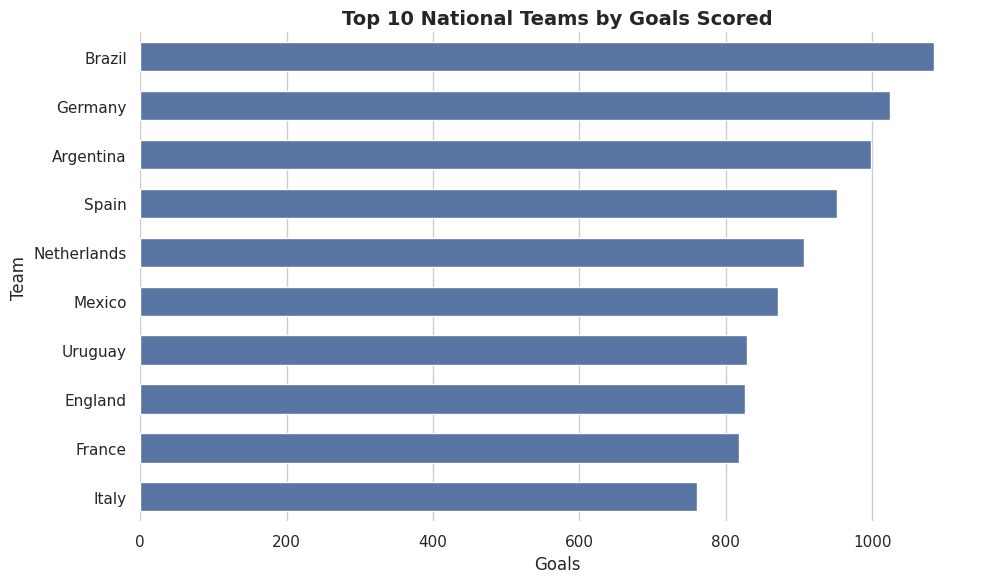

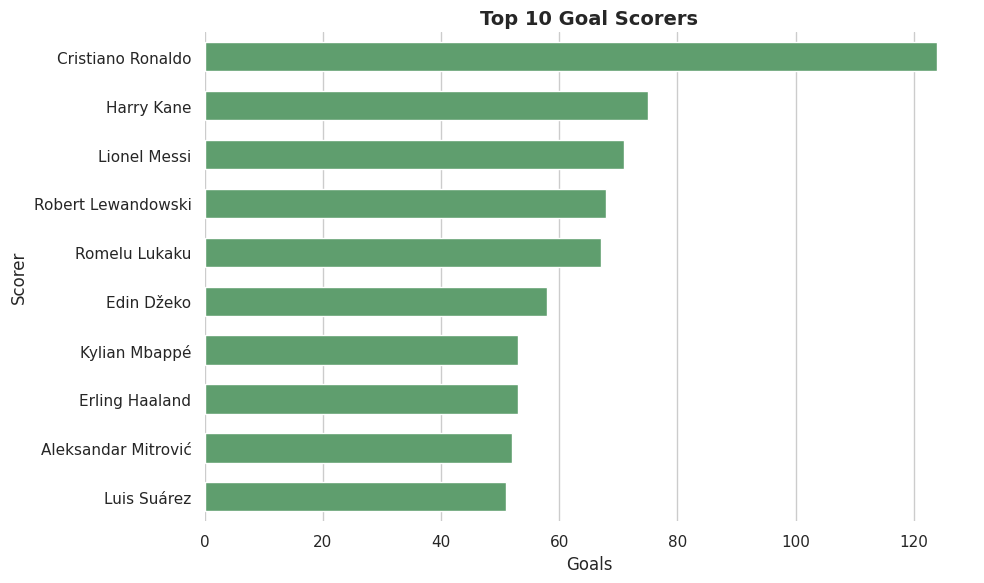

In [19]:
football_analysis.top_10_performers()

## TOP PTS / EFF

          team   pts
0       Brazil  2188
1      England  2023
2    Argentina  2015
3      Germany  1936
4  South Korea  1821
5       Sweden  1782
6       Mexico  1731
7        Italy  1656
8       France  1608
9      Hungary  1545 

          team  efficiency
0       Brazil     4361.00
1      England     4080.18
2      Germany     4035.00
3    Argentina     3956.18
4       Sweden     3749.00
5  South Korea     3473.00
6       Mexico     3360.00
7      Hungary     3300.00
8       France     3224.76
9        Italy     3165.00


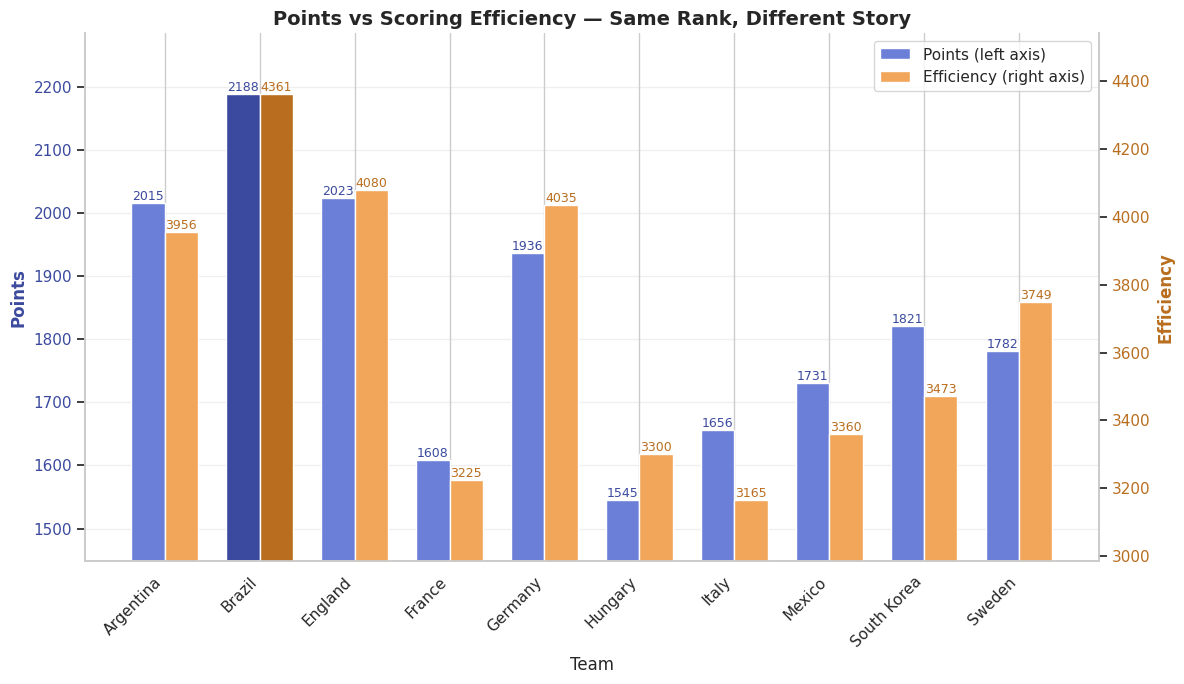

In [20]:
football_analysis.top_10_efficiency()

## Drama Analysis

Shootouts per decade
decade
2010    152
2000    144
1990    126
2020    124
1980     97
1970     38
1960      1
Name: count, dtype: int64 


Shootouts per Tournament
tournament
Friendly                    79
COSAFA Cup                  63
African Cup of Nations      47
FIFA World Cup              39
Copa América                33
                            ..
Great Wall Cup               1
COSAFA Cup qualification     1
TIFOCO Tournament            1
Matthews Cup                 1
Corsica Cup                  1
Name: count, Length: 90, dtype: int64


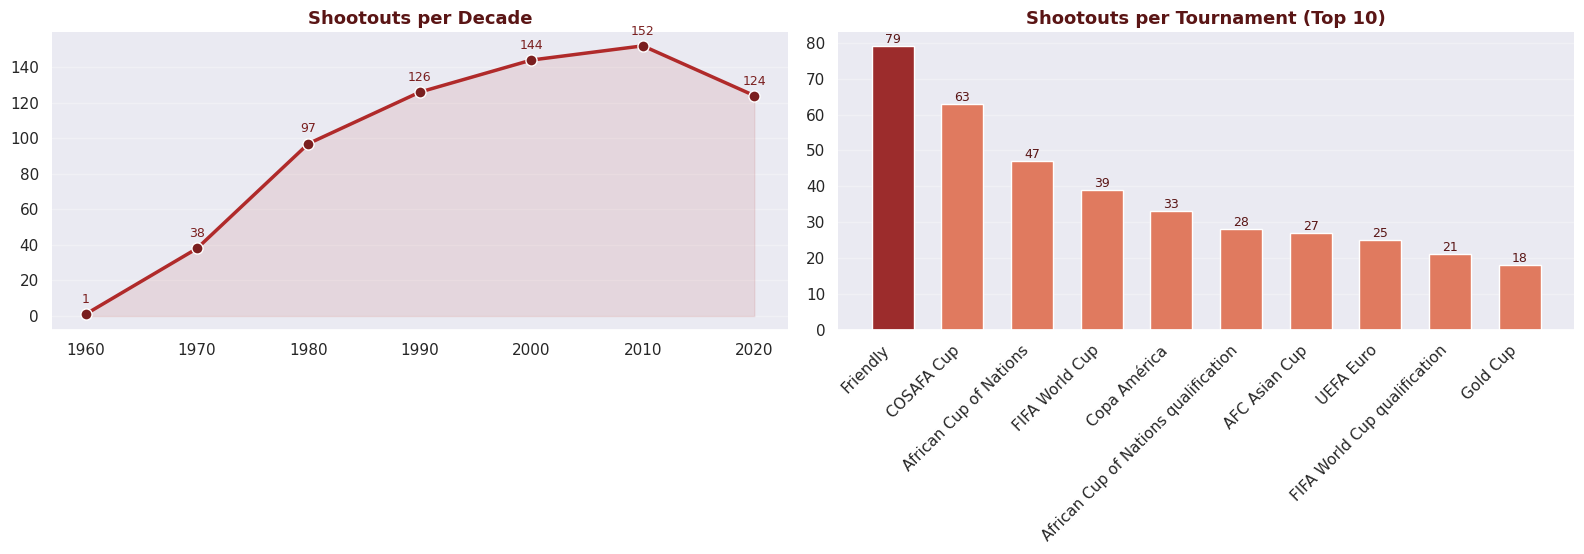

In [21]:
football_analysis.drama_analysis()

## Worst Performers

Worst Performers by number of failures
first_scorer
Brazil                      57
Switzerland                 53
Uruguay                     52
Sweden                      51
Republic of Ireland         50
                            ..
Macau                        1
Mongolia                     1
Montserrat                   1
Nepal                        1
Turks and Caicos Islands     1
Length: 210, dtype: int64
Worst Performers by percentages
                        times_scored_first  failed_after_leading  fail_pct
first_scorer                                                              
Eritrea                                  2                   2.0     100.0
Yemen DPR                                1                   1.0     100.0
British Virgin Islands                   1                   1.0     100.0
Cayman Islands                           4                   3.0      75.0
Laos                                     7                   5.0      71.4
...                     

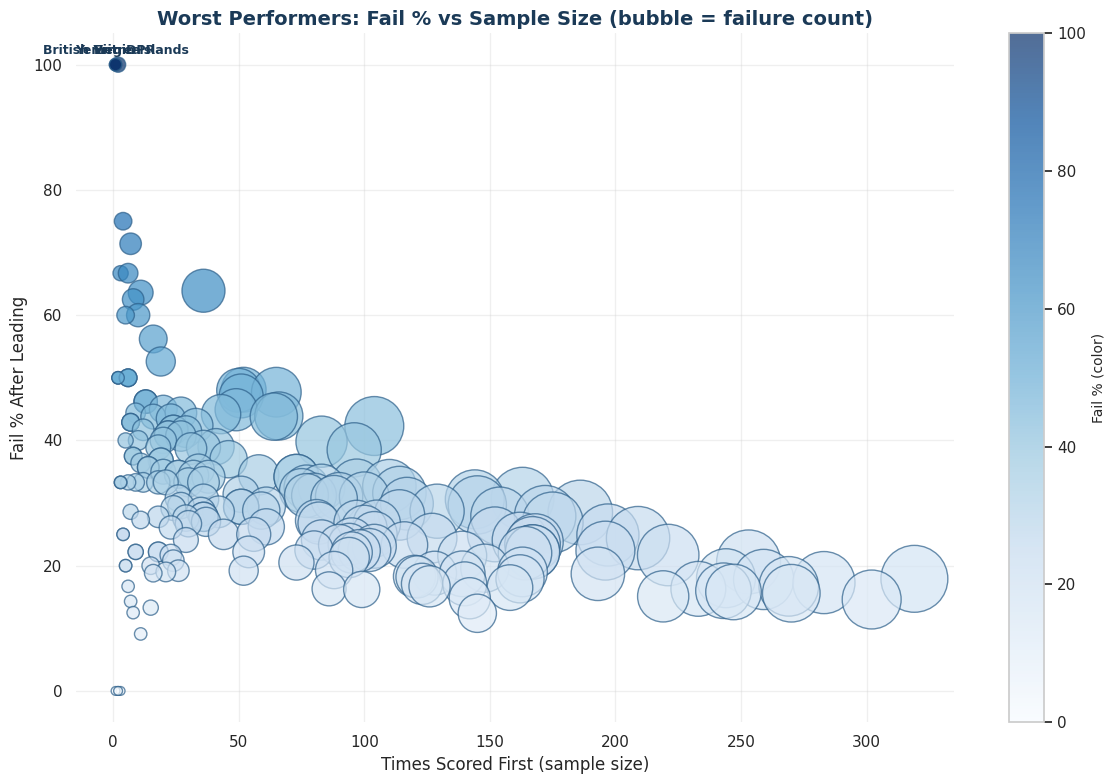

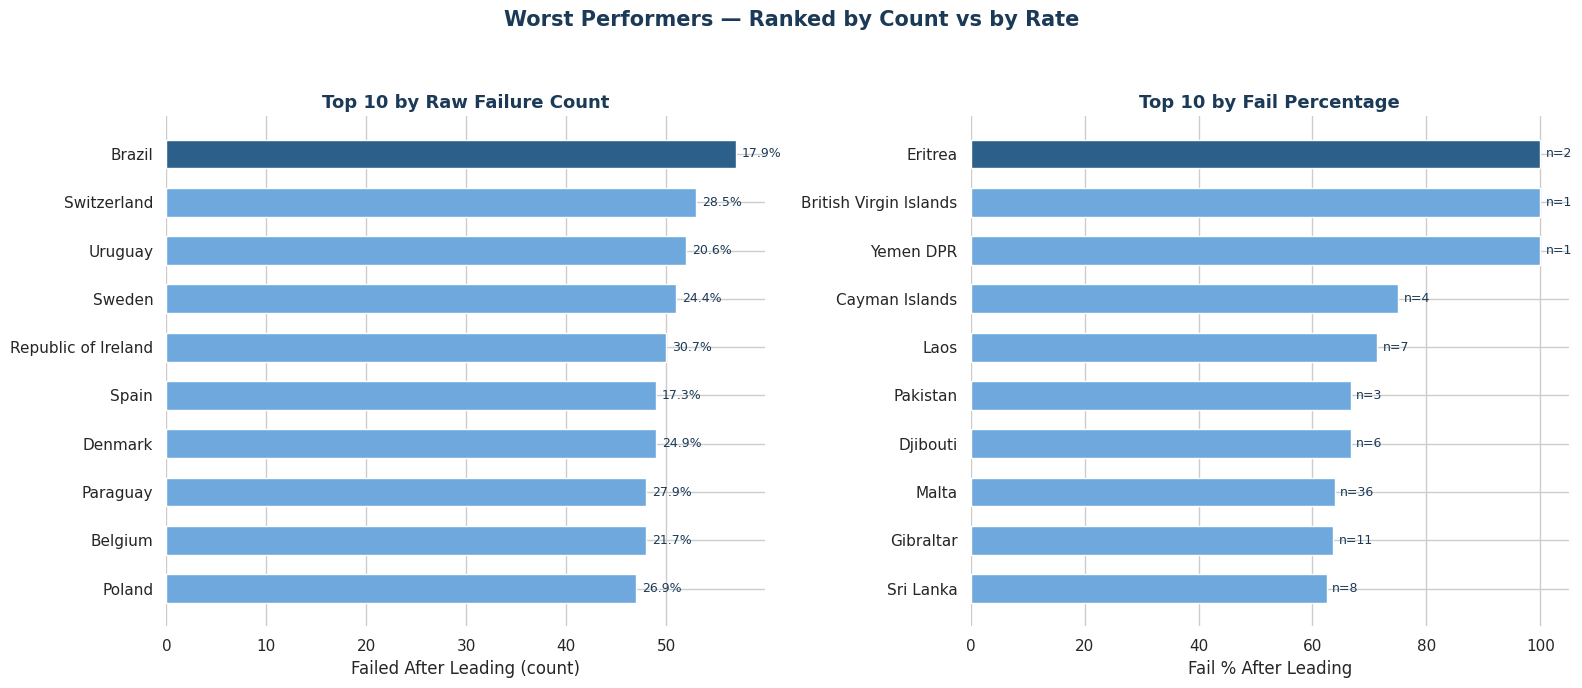

In [22]:
football_analysis.worst_performance()

## Decades Comparison

/tmp/ipykernel_9755/2166780696.py:256: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = era_df.groupby("decade").apply(lambda decade: pd.Series(
/tmp/ipykernel_9755/2166780696.py:268: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_results = year_df.groupby("year").apply(lambda year: pd.Series(


        goals_per_match  draw_rate  avg_margin
decade                                        
1870           4.166667   0.166667    2.000000
1880           4.666667   0.111111    3.066667
1890           4.538462   0.173077    2.384615
1900           3.687500   0.187500    1.828125
1910           3.809061   0.171521    1.873786
1920           3.640605   0.187894    1.842371
1930           4.031465   0.169125    1.811209
1940           3.955787   0.166450    2.015605
1950           3.729712   0.193610    1.770607
1960           3.279458   0.202642    1.729232
1970           2.813832   0.223599    1.573376
1980           2.440500   0.264825    1.396531
1990           2.616839   0.249188    1.492762
2000           2.633950   0.240163    1.513975
2010           2.586290   0.238305    1.499110
2020           2.618807   0.234836    1.531513


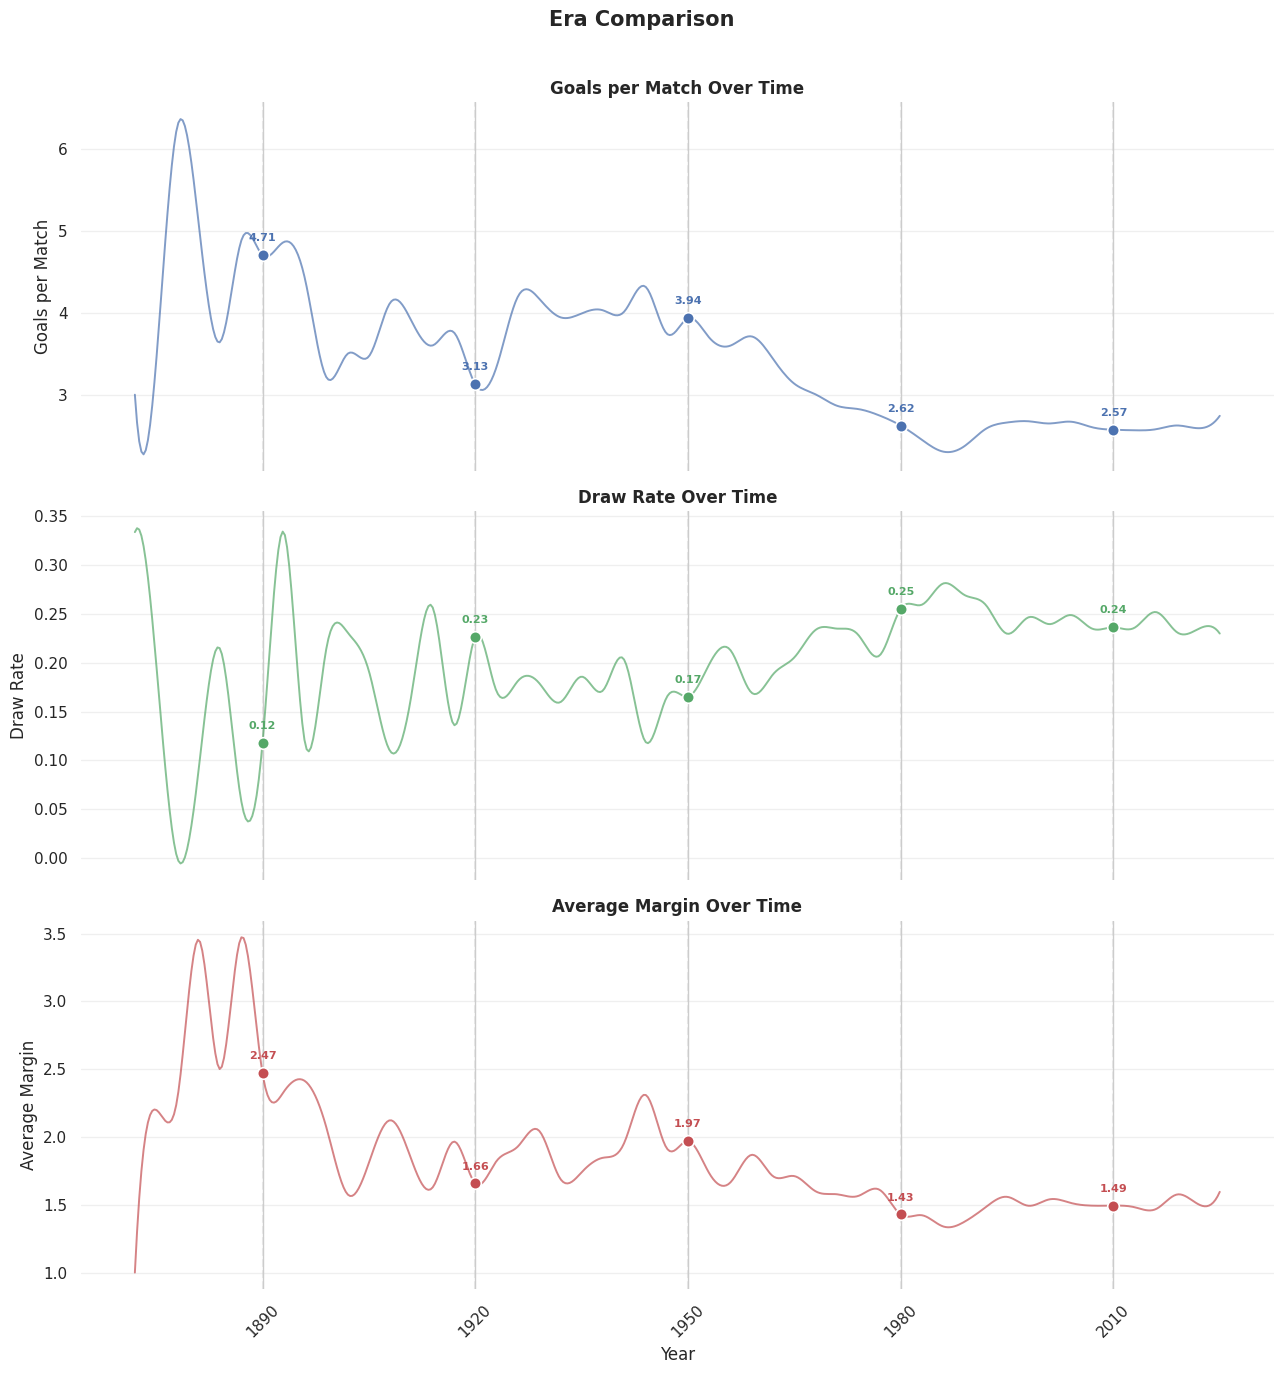

In [23]:
football_analysis.era_comparison()

In [25]:
football_analysis.team_goals_over_years("Argentina")